# Import Libraries and Modules

In [1]:
import sys
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Import preprocessing module from backend
sys.path.append("..")
from backend.app.ml.preprocessing import prepare_data

# Load Master Dataset and Prepare Data

In [2]:
FILE_PATH = "../dataset/all_zones_complete.csv"

# 1. Load dataset and run preprocessing
df_raw = pd.read_csv(FILE_PATH)
df = prepare_data(df_raw, include_lags=False)

# Verify calendar features
calendar_cols = ["hour", "day_of_week", "month", "is_weekend"]
print(f"Loaded data: {df.shape[0]} rows, {df.shape[1]} columns.")
print(f"Calendar columns: {calendar_cols}")
display(df[["timestamp_local", "zone"] + calendar_cols].head(3))

Loaded data: 59232 rows, 11 columns.
Calendar columns: ['hour', 'day_of_week', 'month', 'is_weekend']


,timestamp_local,zone,hour,day_of_week,month,is_weekend
0,2025-01-01 01:00:00+01:00,SE1,1.0,2.0,1.0,0
1,2025-01-01 02:00:00+01:00,SE1,2.0,2.0,1.0,0
2,2025-01-01 03:00:00+01:00,SE1,3.0,2.0,1.0,0


In [3]:
# Features for clustering (spot price + weather factors)
FEATURES = ["spot_price_eur_mwh", "wind_speed_kmh", "temperature_c"]

# Drop any missing values
df_clean = df.dropna(subset=FEATURES).copy().reset_index(drop=True)
X = df_clean[FEATURES]
print(f"Rows after cleaning: {X.shape[0]}, Features: {X.shape[1]}")

Rows after cleaning: 59232, Features: 3


In [4]:
# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Training data ready: {X_scaled.shape[0]} rows across bidding zones.")

Training data ready: 59232 rows across bidding zones.


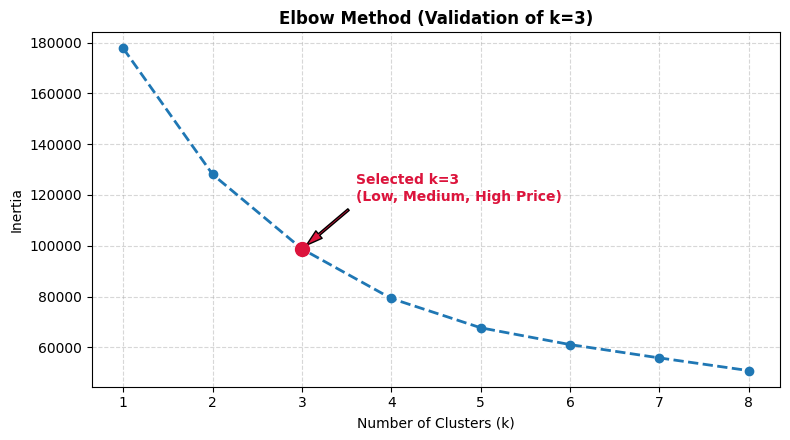

In [5]:
# Compute Inertia for k = 1 to 8
k_range = list(range(1, 9))
inertia = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

# Plot the Elbow curve
plt.figure(figsize=(8, 4.5))
plt.plot(k_range, inertia, marker="o", linestyle="--", color="#1f77b4", linewidth=2)

# Highlight k=3
k_spec = 3
spec_inertia = inertia[k_range.index(k_spec)]
plt.scatter([k_spec], [spec_inertia], color="crimson", s=100, zorder=5)

plt.annotate(
    f"Selected k={k_spec}\n(Low, Medium, High Price)",
    xy=(k_spec, spec_inertia),
    xytext=(k_spec + 0.6, spec_inertia + (max(inertia) - min(inertia)) * 0.15),
    arrowprops=dict(facecolor="crimson", shrink=0.08, width=1.5, headwidth=7),
    fontweight="bold",
    color="crimson",
)

plt.title("Elbow Method (Validation of k=3)", fontsize=12, fontweight="bold")
plt.xlabel("Number of Clusters (k)", fontsize=10)
plt.ylabel("Inertia", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Train Model and Map Clusters

In [6]:
# 1. Train K-Means with k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_clean["cluster_raw"] = kmeans.fit_predict(X_scaled)

# 2. Map clusters by ascending mean price so Low Price is consistently the cheapest
price_order = (
    df_clean.groupby("cluster_raw")["spot_price_eur_mwh"].mean().sort_values().index
)

cluster_labels = {
    price_order[0]: "Low Price",
    price_order[1]: "Medium Price",
    price_order[2]: "High Price",
}

df_clean["price_cluster"] = df_clean["cluster_raw"].map(cluster_labels)
df_clean["cluster"] = df_clean["price_cluster"]

print("Clustering completed and mapped:")
display(
    df_clean.groupby("price_cluster")["spot_price_eur_mwh"]
    .agg(["count", "mean", "min", "max"])
    .round(2)
)

Clustering completed and mapped:


,count,mean,min,max
price_cluster,,,,
High Price,14033,109.25,2.47,486.31
Low Price,18919,21.94,-92.88,162.70
Medium Price,26280,29.58,-23.68,147.04


--- Mean Values per Price Cluster ---


,spot_price_eur_mwh,wind_speed_kmh,temperature_c
price_cluster,,,
Low Price,21.94,21.14,7.13
Medium Price,29.58,9.61,11.03
High Price,109.25,10.37,-0.38



--- Analysis Summary (Typical Factors for Low Price) ---
Spot Price:     21.94 EUR/MWh
Wind Speed:     21.14 km/h
Temperature:    7.13 °C


<Figure size 900x500 with 0 Axes>

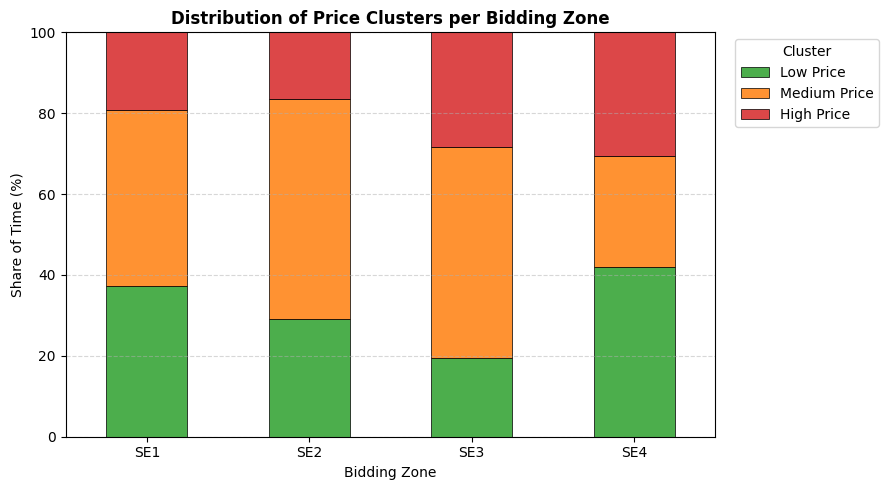

In [7]:
# 1. Compile profile summary per cluster
cluster_summary = (
    df_clean.groupby("price_cluster")[FEATURES]
    .mean()
    .loc[["Low Price", "Medium Price", "High Price"]]
    .round(2)
)

print("--- Mean Values per Price Cluster ---")
display(cluster_summary)

low = cluster_summary.loc["Low Price"]
print("\n--- Analysis Summary (Typical Factors for Low Price) ---")
print(f"Spot Price:     {low['spot_price_eur_mwh']} EUR/MWh")
print(f"Wind Speed:     {low['wind_speed_kmh']} km/h")
print(f"Temperature:    {low['temperature_c']} °C")

# 2. Stacked bar chart showing cluster distribution per bidding zone
zone_dist = (
    pd.crosstab(df_clean["zone"], df_clean["price_cluster"], normalize="index")[
        ["Low Price", "Medium Price", "High Price"]
    ]
    * 100
)

plt.figure(figsize=(9, 5))
ax = zone_dist.plot(
    kind="bar",
    stacked=True,
    color=["#2ca02c", "#ff7f0e", "#d62728"],
    figsize=(9, 5),
    edgecolor="black",
    linewidth=0.6,
    alpha=0.85,
)
plt.title("Distribution of Price Clusters per Bidding Zone", fontweight="bold")
plt.xlabel("Bidding Zone")
plt.ylabel("Share of Time (%)")
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

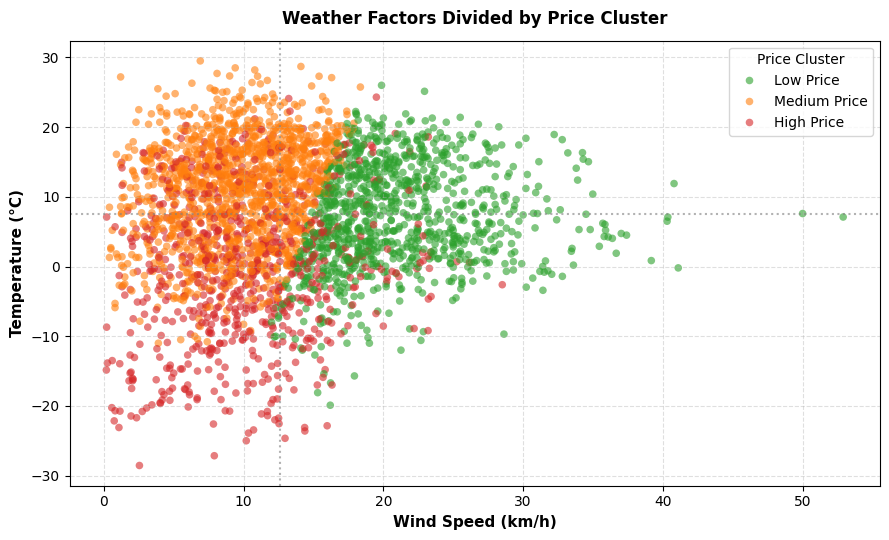

In [8]:
# Scatter plot of weather factors per price cluster
sample_df = df_clean.sample(n=min(3000, len(df_clean)), random_state=42)

palette = {
    "Low Price": "#2ca02c",
    "Medium Price": "#ff7f0e",
    "High Price": "#d62728",
}

plt.figure(figsize=(9, 5.5))
sns.scatterplot(
    data=sample_df,
    x="wind_speed_kmh",
    y="temperature_c",
    hue="price_cluster",
    hue_order=["Low Price", "Medium Price", "High Price"],
    palette=palette,
    alpha=0.6,
    edgecolor="none",
    s=30,
)

plt.title(
    "Weather Factors Divided by Price Cluster",
    fontsize=12,
    fontweight="bold",
    pad=12,
)
plt.xlabel("Wind Speed (km/h)", fontsize=11, fontweight="bold")
plt.ylabel("Temperature (°C)", fontsize=11, fontweight="bold")
plt.axvline(
    x=sample_df["wind_speed_kmh"].median(), color="gray", linestyle=":", alpha=0.6
)
plt.axhline(
    y=sample_df["temperature_c"].median(), color="gray", linestyle=":", alpha=0.6
)

plt.legend(title="Price Cluster", frameon=True, loc="upper right")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# Save Model, Scaler, and Clustered Dataset

In [9]:
# 1. Define output directories
model_dir = Path("../models_bin")
dataset_dir = Path("../dataset")

model_dir.mkdir(parents=True, exist_ok=True)
dataset_dir.mkdir(parents=True, exist_ok=True)

# 2. Save artifacts in models_bin
model_path = model_dir / "kmeans_zone_model.pkl"
scaler_path = model_dir / "scaler_zone.pkl"

joblib.dump(kmeans, model_path)
joblib.dump(scaler, scaler_path)

# 3. Save the enriched dataset
output_dataset = dataset_dir / "all_zones_clustered_long.csv"
df_clean.to_csv(output_dataset, index=False)

print("Saved:")
print(f" - Model:    {model_path}")
print(f" - Scaler:   {scaler_path}")
print(f" - Dataset:  {output_dataset}")

Saved:
 - Model:    ..\models_bin\kmeans_zone_model.pkl
 - Scaler:   ..\models_bin\scaler_zone.pkl
 - Dataset:  ..\dataset\all_zones_clustered_long.csv
